# Non-IID Feature Screening Algorithm

Detects features that likely violate the IID assumption by comparing KFold vs TimeSeriesSplit correlation gap variance.

- **High TSSplit/KFold variance ratio** → feature has row-order-dependent structure → potential IID violation
- **Threshold**: ratio > 2.0 (default) flags a feature as suspicious
- **No time column or domain knowledge required**

In [1]:
import warnings
from scipy.stats import ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)

import importlib
import screen_non_iid
importlib.reload(screen_non_iid)
from screen_non_iid import screen_non_iid_features

import pandas as pd
import matplotlib.pyplot as plt

## Experiment 1: Online News Popularity (cross-sectional)

Originally a cross-sectional dataset — weak temporal signal expected.

In [2]:
data = pd.read_csv("OnlineNewsPopularity.csv")
data.columns = data.columns.str.strip()

X = data.drop(["shares", "url"], axis=1)
y = data["shares"]

result_news = screen_non_iid_features(X, y, n_splits=5, ratio_threshold=2.0)
print(result_news.to_string(index=False))

                      feature  pearson_ratio  spearman_ratio
         data_channel_is_tech       7.268344        1.065882
                       LDA_04       5.127492        0.949443
data_channel_is_entertainment       2.684952        0.692736
                   kw_max_min       2.435606        0.680475
    global_sentiment_polarity       2.257496        0.072212
                   kw_avg_min       2.225724        2.193869
    self_reference_max_shares       2.142653        0.853435
         weekday_is_wednesday       2.130186        3.470053
                    num_hrefs       2.020841        0.780280
        min_positive_polarity       1.395440        2.662570
                    timedelta       0.898887        2.194444
            weekday_is_friday       0.372655        2.861326
           weekday_is_tuesday       0.307500        2.287599
                   kw_max_max       0.146012        3.663770


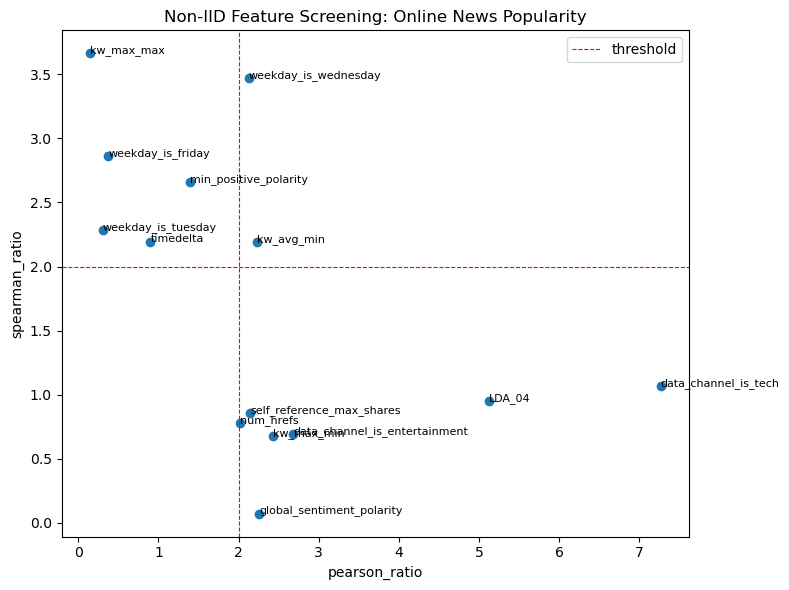

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(result_news["pearson_ratio"], result_news["spearman_ratio"])
for _, row in result_news.iterrows():
    ax.annotate(row["feature"], (row["pearson_ratio"], row["spearman_ratio"]), fontsize=8)
ax.axvline(2.0, color="red", linestyle="--", linewidth=0.8, label="threshold")
ax.axhline(2.0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("pearson_ratio")
ax.set_ylabel("spearman_ratio")
ax.set_title("Non-IID Feature Screening: Online News Popularity")
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 2: Air Quality UCI (time series)

Genuine time series dataset — strong temporal signal expected.

In [5]:
data2 = pd.read_csv("AirQualityUCI.csv")
data2 = data2.dropna(how="all").dropna(axis=1, how="all")

X2 = data2.drop(["CO(GT)", "Date", "Time"], axis=1)
y2 = data2["CO(GT)"]

result_air = screen_non_iid_features(X2, y2, n_splits=5, ratio_threshold=2.0)
print(result_air.to_string(index=False))

      feature  pearson_ratio  spearman_ratio
           RH       4.948826        0.564817
 PT08.S4(NO2)       4.630161        4.126265
            T       4.205884        2.003987
           AH       3.080044        2.372296
     C6H6(GT)       2.711870        2.530188
PT08.S2(NMHC)       2.447049        2.531792
  PT08.S5(O3)       1.678705        2.434071
      NOx(GT)       0.318164        2.481546


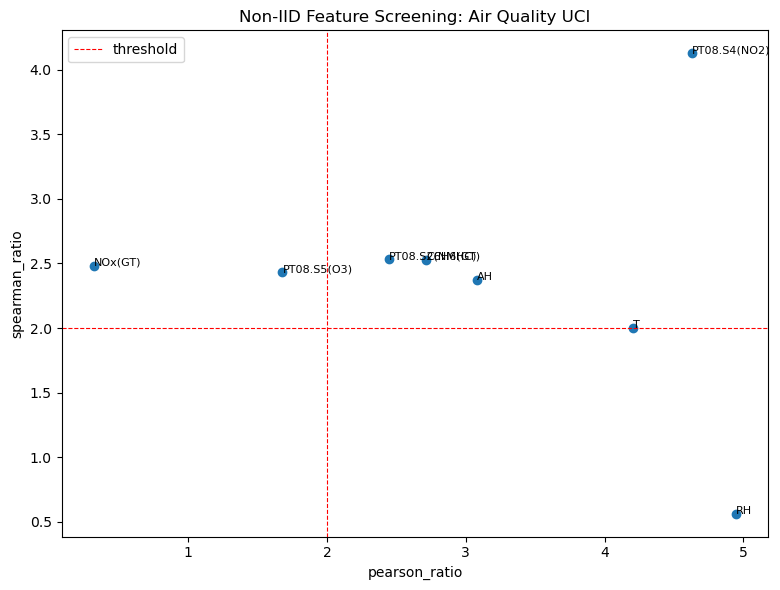

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(result_air["pearson_ratio"], result_air["spearman_ratio"])
for _, row in result_air.iterrows():
    ax.annotate(row["feature"], (row["pearson_ratio"], row["spearman_ratio"]), fontsize=8)
ax.axvline(2.0, color="red", linestyle="--", linewidth=0.8, label="threshold")
ax.axhline(2.0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("pearson_ratio")
ax.set_ylabel("spearman_ratio")
ax.set_title("Non-IID Feature Screening: Air Quality UCI")
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 3: Wine (IID)

Purely IID dataset — no flagged features expected.

In [7]:
from sklearn.datasets import load_wine

data3 = load_wine()
X3 = pd.DataFrame(data3.data, columns=data3.feature_names)
y3 = pd.Series(data3.target)

result_wine = screen_non_iid_features(X3, y3, n_splits=5, ratio_threshold=2.0)
print(result_wine)

Empty DataFrame
Columns: [feature, pearson_ratio, spearman_ratio]
Index: []
